#Grupo de Aplicações de Inteligência Artificial
- Lucas de Oliveira Ferreira
- João Brasileiro


# Urban Issues

Este notebook aborda o dataset do Kaggle **akinduhiman/urban-issues-dataset**. Tentando criar um modelo de classificaçao de imagens em classes de problemas hurbanos.


In [ ]:
import os
import sys
import glob
import json
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm import tqdm

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline

import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display

import kagglehub
from google.colab import files

import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras import layers, Model

print("Setup complete.")

Setup complete.


# Mapeamento dos dados
Baixa o dataset via `kagglehub`, percorre diretórios para indexar caminhos de imagem e rótulos, e constrói `DataFrame`s com colunas padrão (`path`/`label_id`).


In [ ]:
# 1) Baixa dataset
path = kagglehub.dataset_download("akinduhiman/urban-issues-dataset")
print("Path to dataset files:", path)
root = Path(path)
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# 2) Indexa imagens (stem -> caminho) procurando pastas 'images' no dataset todo
def build_image_index(root: Path):
    idx = {}
    for imdir in root.rglob("images"):
        if not imdir.is_dir():
            continue
        for p in imdir.rglob("*"):
            if p.suffix.lower() in IMG_EXTS:
                idx.setdefault(p.stem, str(p.resolve()))
    return idx

img_index = build_image_index(root)

# 3) Varre labels/*.txt e define rótulo da imagem como a classe dominante por área (w*h)
rows = []
for lbdir in root.rglob("labels"):
    if not lbdir.is_dir():
        continue
    for lf in lbdir.rglob("*.txt"):
        stem = lf.stem
        img_path = img_index.get(stem)
        if img_path is None:
            continue
        try:
            lines = [ln.strip() for ln in open(lf, "r").read().splitlines() if ln.strip()]
        except Exception:
            continue
        if not lines:
            continue

        area = {}
        for ln in lines:
            parts = ln.split()
            if len(parts) < 5:
                continue
            cls_id = int(float(parts[0]))
            w = float(parts[3]); h = float(parts[4])
            area[cls_id] = area.get(cls_id, 0.0) + (w * h)

        if not area:
            continue
        total = sum(area.values())
        dom_id, dom_area = max(area.items(), key=lambda kv: kv[1])
        dom_frac = (dom_area / total) if total > 0 else 1.0
        rows.append({"path": img_path, "label_id": int(dom_id), "dom_frac": float(dom_frac)})

df = pd.DataFrame(rows).drop_duplicates(subset=["path"]).reset_index(drop=True)
if df.empty or df["label_id"].nunique() < 2:
    raise RuntimeError("Não foi possível montar múltiplas classes a partir de labels/*.txt.")

# Mapeia labels
id2name = {
    0: "Damaged Road issues (Road cracks)",
    1: "Pothole Issues",
    2: "Illegal Parking Issues",
    3: "Broken Road Sign Issues",
    4: "Fallen trees",
    5: "Littering/Garbage on Public Places",
    6: "Vandalism Issues (Graffitti)",
    7: "Dead Animal Pollution",
    8: "Damaged concrete structures",
    9: "Damaged Electric wires and poles",
}
df["label_id"] = df["label_id"].astype(int)
df["label"] = df["label_id"].map(lambda i: id2name.get(i, f"class_{i}"))

print("\nDistribuição por id (global):")
print(df["label_id"].value_counts().sort_index())

# 6) Deriva split a partir do caminho: train / valid / test
def get_split_from_path(p: str):
    parts = [s.lower() for s in Path(p).parts]
    if "train" in parts: return "train"
    if "valid" in parts: return "valid"
    if "test"  in parts: return "test"
    return None

df["split"] = df["path"].map(get_split_from_path)
df = df[df["split"].notna()].reset_index(drop=True)

# 7) DataFrames finais por split
df_train = df[df["split"] == "train"].reset_index(drop=True)
df_val   = df[df["split"] == "valid"].reset_index(drop=True)
df_test  = df[df["split"] == "test"].reset_index(drop=True)

# 8) Relatórios rápidos
def report_split(name, dfi):
    if len(dfi) == 0:
        print(f"[{name}] vazio.")
        return
    print(f"\n[{name}] n={len(dfi)} | #classes={dfi['label_id'].nunique()}")
    print(dfi["label_id"].value_counts().sort_index())

for sp_name, dfi in [("train", df_train), ("valid", df_val), ("test", df_test)]:
    report_split(sp_name, dfi)

print("\nExemplo df:")
display(df.head(3))


Using Colab cache for faster access to the 'urban-issues-dataset' dataset.
Path to dataset files: /kaggle/input/urban-issues-dataset

Distribuição por id (global):
label_id
0     2675
1     4881
2      175
3     2295
4    11112
5     4052
6     1993
7      192
8    11727
9     7586
Name: count, dtype: int64

[train] n=37730 | #classes=10
label_id
0    1863
1    4030
2     133
3    2215
4    8498
5    3061
6    1596
7     153
8    9282
9    6899
Name: count, dtype: int64

[valid] n=4831 | #classes=10
label_id
0     753
1     509
2      24
3      41
4     982
5     660
6     203
7      25
8    1225
9     409
Name: count, dtype: int64

[test] n=4127 | #classes=10
label_id
0      59
1     342
2      18
3      39
4    1632
5     331
6     194
7      14
8    1220
9     278
Name: count, dtype: int64

Exemplo df:


,path,label_id,dom_frac,label,split
0,/kaggle/input/urban-issues-dataset/FallenTrees...,4,1.0,Fallen trees,valid
1,/kaggle/input/urban-issues-dataset/FallenTrees...,4,1.0,Fallen trees,valid
2,/kaggle/input/urban-issues-dataset/FallenTrees...,4,1.0,Fallen trees,valid


# Pré-processamento

Define funções para carregar as imagens de acordo com os caminhos fornecidos, criar os dataframes a serem passados para os modelos e mostrar alguns exemplos de imagens da base.

In [ ]:
IMG_SIZE, BATCH, AUTOTUNE = 224, 32, tf.data.AUTOTUNE

def _load(path, y):
    x = tf.image.decode_image(tf.io.read_file(path), channels=3, expand_animations=False)
    x.set_shape([None, None, 3])
    x = tf.image.resize(x, (IMG_SIZE, IMG_SIZE))
    x = tf.cast(x, tf.float32)
    return preprocess_input(x), y

def make_ds(paths, ys, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, ys))
    if shuffle: ds = ds.shuffle(len(paths), reshuffle_each_iteration=True)
    return ds.map(_load, num_parallel_calls=AUTOTUNE).batch(BATCH).prefetch(AUTOTUNE)

def show_samples(paths, labels, n=12):
    p, r = paths[:n], labels[:n]
    rows, cols = int(np.ceil(n/6)), 6
    plt.figure(figsize=(cols*2, rows*2))
    for i, (fp, lb) in enumerate(zip(p, r), 1):
        img = tf.image.decode_image(tf.io.read_file(fp), channels=3).numpy()
        plt.subplot(rows, cols, i); plt.imshow(img); plt.axis("off"); plt.title(int(lb))
    plt.tight_layout(); plt.show()


Mostra os exemplos.

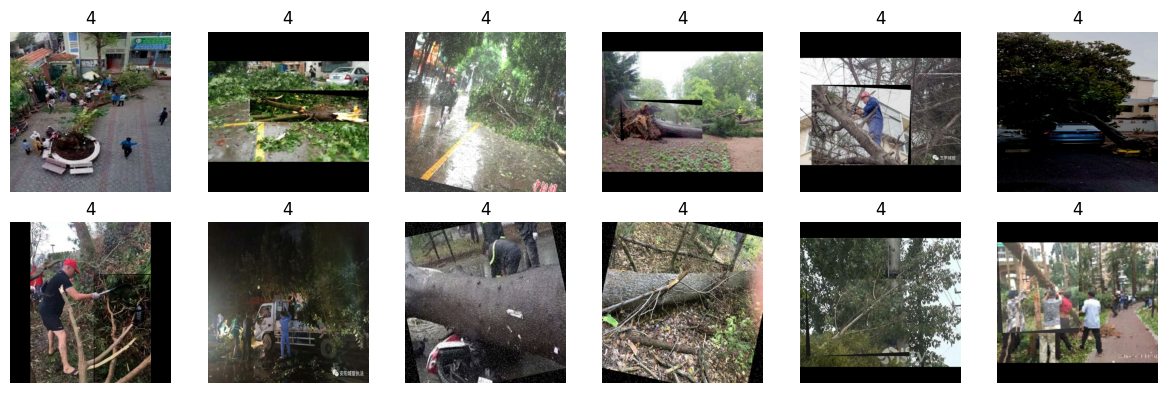

In [ ]:
show_samples(df_train["path"].values, df_train["label_id"].values, n=12)


Cria Dataframes.

In [ ]:
ds_tr = make_ds(df_train["path"].values, df_train["label_id"].values, shuffle=True)
ds_va = make_ds(df_val["path"].values, df_val["label_id"].values, shuffle=False)
ds_te = make_ds(df_test["path"].values, df_test["label_id"].values, shuffle=False)


# Carregamento do modelo EfficientNetB0

Carrega modelo pré-treinado.

In [ ]:
base = EfficientNetB0(include_top=False, weights="imagenet", input_shape=(IMG_SIZE, IMG_SIZE, 3))
base.trainable = False
embed_model = Model(base.input, layers.GlobalAveragePooling2D()(base.output))


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


# Geração de Embeddings das Imagens
Usa o modelo para gerar embeddings das imagens.

In [ ]:
def to_emb(ds):
    feats, labs = [], []
    for bx, by in ds:
        f = embed_model.predict(bx, verbose=0)
        feats.append(f); labs.append(by.numpy())
    return np.concatenate(feats, 0), np.concatenate(labs, 0)

X_tr, y_tr = to_emb(ds_tr)
X_va, y_va = to_emb(ds_va)
X_te, y_te = to_emb(ds_te)


# Treinamento e Avaliação

## Regressão Logística
Com um modelo de regresão logística obtemos cerca de 95% de acurácia e 90% de F1-macro.

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Melhores parâmetros encontrados:
{'logisticregression__C': 0.1, 'logisticregression__class_weight': 'balanced', 'logisticregression__penalty': 'l2'}
Melhor média F1 (validação cruzada): 0.9413969704697426

Desempenho no teste - Acc: 0.9484 | F1-macro: 0.8985

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.64      0.92      0.75        59
           1       0.91      0.70      0.79       342
           2       0.84      0.89      0.86        18
           3       0.93      0.95      0.94        39
           4       0.99      0.98      0.99      1632
           5       0.84      0.98      0.90       331
           6       0.87      0.88      0.87       194
           7       0.93      1.00      0.97        14
           8       0.98      0.98      0.98      1220
           9       0.92      0.96      0.94       278

    accuracy                           0.95      4127
  

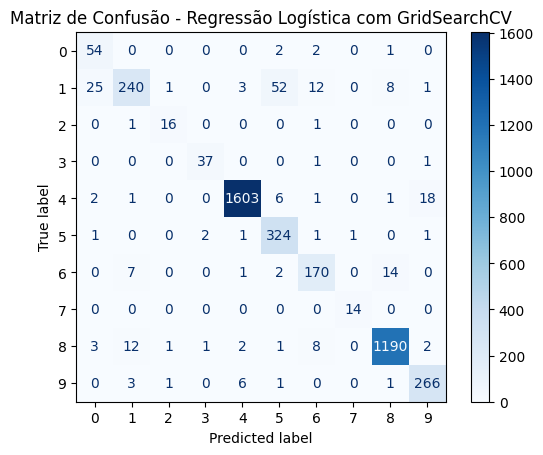

In [ ]:
# 1. Combinar treino + validação
X_trva = np.vstack([X_tr, X_va])
y_trva = np.concatenate([y_tr, y_va])

# 2. Definir pipeline base
pipe = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        max_iter=2000,
        n_jobs=-1,
        solver="lbfgs"
    )
)

# 3. Definir espaço de busca de hiperparâmetros
param_grid = {
    "logisticregression__class_weight": [None, "balanced"],
    "logisticregression__C": [0.01, 0.1, 1, 10],
    "logisticregression__penalty": ["l2"],  # lbfgs não suporta l1
}

# 4. Configurar o GridSearchCV
grid = GridSearchCV(
    pipe,
    param_grid=param_grid,
    cv=3,  # ou 5 dependendo do tamanho do dataset
    scoring="f1_macro",  # pode trocar por "accuracy"
    n_jobs=-1,
    verbose=2
)

# 5. Executar o grid search
grid.fit(X_trva, y_trva)

# 6. Mostrar melhores parâmetros e resultado
print("Melhores parâmetros encontrados:")
print(grid.best_params_)
print("Melhor média F1 (validação cruzada):", grid.best_score_)

# 7. Avaliar no conjunto de teste
best_model = grid.best_estimator_
y_pred = best_model.predict(X_te)

# 8. Métricas finais
acc = accuracy_score(y_te, y_pred)
f1m = f1_score(y_te, y_pred, average="macro")

print(f"\nDesempenho no teste - Acc: {acc:.4f} | F1-macro: {f1m:.4f}\n")
print("Relatório de Classificação:")
print(classification_report(y_te, y_pred))

# 9. Matriz de confusão
cm = confusion_matrix(y_te, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Matriz de Confusão - Regressão Logística com GridSearchCV")
plt.show()

## MLP

Com uma rede neural simples conseguimos uma acurácia de aproximadamente 96% e 92% de F1-macro.

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Melhores parâmetros encontrados:
{'mlpclassifier__hidden_layer_sizes': (128, 64)}
Melhor média F1 (validação cruzada): 0.949130608540622

Desempenho no teste - Acc: 0.9661 | F1-macro: 0.9232

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.71      0.88      0.79        59
           1       0.95      0.81      0.88       342
           2       1.00      0.83      0.91        18
           3       0.97      0.95      0.96        39
           4       0.99      0.99      0.99      1632
           5       0.93      0.98      0.96       331
           6       0.90      0.90      0.90       194
           7       1.00      0.86      0.92        14
           8       0.98      0.99      0.99      1220
           9       0.94      0.95      0.95       278

    accuracy                           0.97      4127
   macro avg       0.94      0.91      0.92      4127
weighted avg     

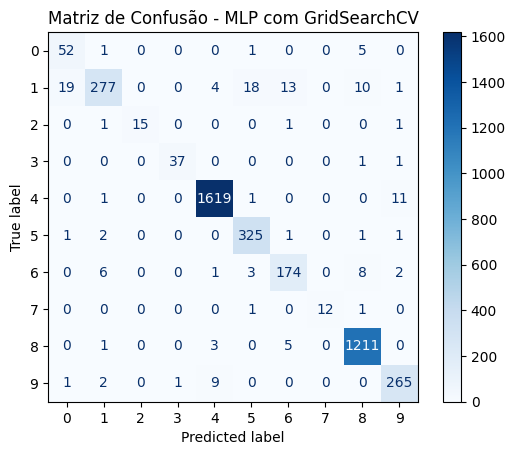

In [ ]:
# 1. Combinar treino + validação
X_trva = np.vstack([X_tr, X_va])
y_trva = np.concatenate([y_tr, y_va])

# 2. Definir pipeline base
pipe = make_pipeline(
    StandardScaler(),
    MLPClassifier(
        activation="relu",
        early_stopping=True,
        n_iter_no_change=10,
        random_state=42
    )
)

# 3. Definir espaço de busca de hiperparâmetros
param_grid = {
    "mlpclassifier__hidden_layer_sizes": [(64,), (128, 64), (256, 128, 64)],
}

# 4. Configurar o GridSearchCV
grid = GridSearchCV(
    pipe,
    param_grid=param_grid,
    cv=3,  # ou 5, dependendo do tamanho do dataset
    scoring="f1_macro",  # ou "accuracy"
    n_jobs=-1,
    verbose=2
)

# 5. Executar o grid search
grid.fit(X_trva, y_trva)

# 6. Mostrar melhores parâmetros e resultado
print("Melhores parâmetros encontrados:")
print(grid.best_params_)
print("Melhor média F1 (validação cruzada):", grid.best_score_)

# 7. Avaliar no conjunto de teste
best_model = grid.best_estimator_
y_pred = best_model.predict(X_te)

# 8. Métricas finais
acc = accuracy_score(y_te, y_pred)
f1m = f1_score(y_te, y_pred, average="macro")

print(f"\nDesempenho no teste - Acc: {acc:.4f} | F1-macro: {f1m:.4f}\n")
print("Relatório de Classificação:")
print(classification_report(y_te, y_pred))

# 9. Matriz de confusão
cm = confusion_matrix(y_te, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Matriz de Confusão - MLP com GridSearchCV")
plt.show()


Tentamos também treinar uma CNN com as imagens, porém além do processo ser muito lento, a eficiência não foi satisfatoria, chegando a apenas cerca de 50% de acurácia depois de horas de treinamento.

# Conclusão

O uso de modelos pré-treinados para obtenção de embeddings de imagem se mostra uma estratégia robusta e eficaz em cenários onde a falta de poder computacional e/ou dados impactaria no treinamento de um modelo do zero.

# Assistente Inteligente

Recebe imagens do usuário e retorna classificação em uma das 10 classes possíveis.

Loop de classificação iniciado. Para encerrar, interrompa a execução da célula (Stop/KeyboardInterrupt).

📥 Selecione 1 ou mais imagens para classificar:


Saving 155_jpg.rf.7fa4c307531b2bd38d3374a0f7c64c6f.jpg to 155_jpg.rf.7fa4c307531b2bd38d3374a0f7c64c6f.jpg

— Arquivo recebido: 155_jpg.rf.7fa4c307531b2bd38d3374a0f7c64c6f.jpg


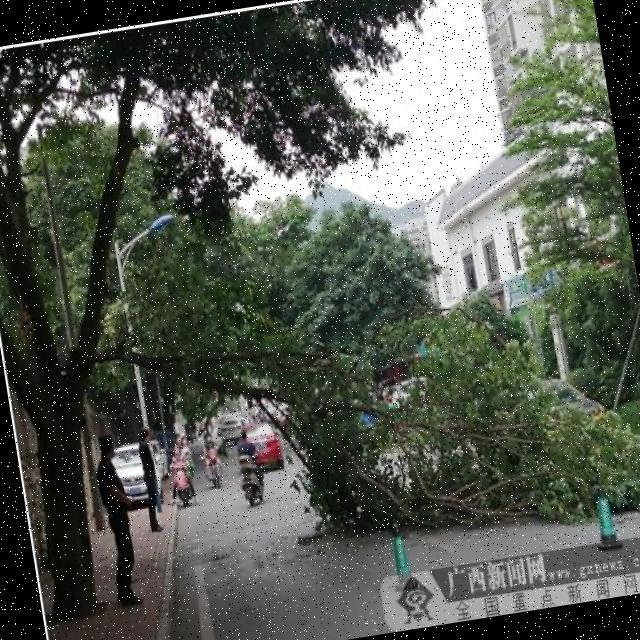

Lote: (1, 224, 224, 3)
✅ Predição: Quedas de árvores
🗑️ Arquivo deletado: 155_jpg.rf.7fa4c307531b2bd38d3374a0f7c64c6f.jpg

Pronto! Você pode enviar novas imagens na próxima caixa de upload…

📥 Selecione 1 ou mais imagens para classificar:


Saving 2013-02-22_12_20_06_jpg.rf.1c319c18357ed402c69ea24b7fa112a7.jpg to 2013-02-22_12_20_06_jpg.rf.1c319c18357ed402c69ea24b7fa112a7.jpg

— Arquivo recebido: 2013-02-22_12_20_06_jpg.rf.1c319c18357ed402c69ea24b7fa112a7.jpg


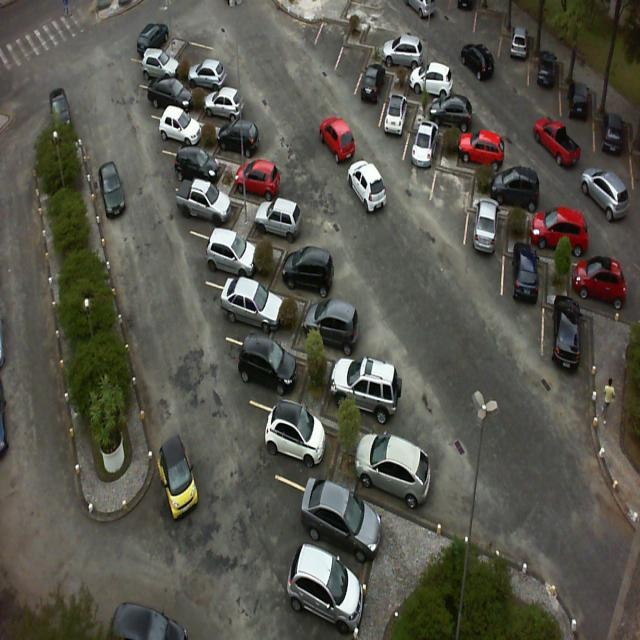

Lote: (1, 224, 224, 3)
✅ Predição: Problemas de estacionamento irregular
🗑️ Arquivo deletado: 2013-02-22_12_20_06_jpg.rf.1c319c18357ed402c69ea24b7fa112a7.jpg

Pronto! Você pode enviar novas imagens na próxima caixa de upload…

📥 Selecione 1 ou mais imagens para classificar:


Saving Dead-Animals-Pollution_original_dead--14--jpg_3e563076-d3bb-42b2-87a6-4553b920b9a5_jpg.rf.9b27d5ea1455845ce4d569fa5ca69b28.jpg to Dead-Animals-Pollution_original_dead--14--jpg_3e563076-d3bb-42b2-87a6-4553b920b9a5_jpg.rf.9b27d5ea1455845ce4d569fa5ca69b28.jpg

— Arquivo recebido: Dead-Animals-Pollution_original_dead--14--jpg_3e563076-d3bb-42b2-87a6-4553b920b9a5_jpg.rf.9b27d5ea1455845ce4d569fa5ca69b28.jpg


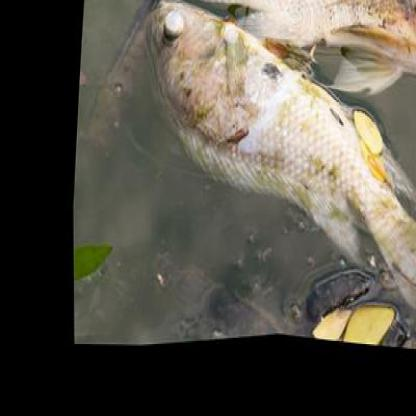

Lote: (1, 224, 224, 3)
✅ Predição: Poluição por animal morto
🗑️ Arquivo deletado: Dead-Animals-Pollution_original_dead--14--jpg_3e563076-d3bb-42b2-87a6-4553b920b9a5_jpg.rf.9b27d5ea1455845ce4d569fa5ca69b28.jpg

Pronto! Você pode enviar novas imagens na próxima caixa de upload…

📥 Selecione 1 ou mais imagens para classificar:


Nenhum arquivo enviado. Repetindo…

📥 Selecione 1 ou mais imagens para classificar:



Encerrando o loop a pedido do usuário.


In [ ]:
id2nameport = {
    0: "Problemas de estrada danificada (rachaduras na via)",
    1: "Problemas de buracos na estrada",
    2: "Problemas de estacionamento irregular",
    3: "Problemas com placas de trânsito danificadas",
    4: "Quedas de árvores",
    5: "Lixo ou entulho em locais públicos",
    6: "Problemas de vandalismo (pichação)",
    7: "Poluição por animal morto",
    8: "Estruturas de concreto danificadas",
    9: "Fios e postes elétricos danificados",
}

print("Loop de classificação iniciado. Para encerrar, interrompa a execução da célula (Stop/KeyboardInterrupt).")

while True:
    try:
        print("\n📥 Selecione 1 ou mais imagens para classificar:")
        uploaded = files.upload()  # abre o seletor de arquivos do Colab

        if not uploaded:
            print("Nenhum arquivo enviado. Repetindo…")
            continue

        # Processa cada arquivo enviado nesta rodada
        for image_filename in uploaded.keys():
            try:
                print(f"\n— Arquivo recebido: {image_filename}")

                # 1) Carrega e exibe a imagem
                image = Image.open(image_filename)
                display(image)

                # 2) Pipeline de inferência (mantendo seus prints)
                path = [image_filename]
                ys = [0]  # rótulo fictício só para satisfazer a assinatura
                ds = make_ds(path, ys)

                for x_batch, _ in ds.take(1):
                    print(f"Lote: {x_batch.shape}")  # (1, 224, 224, 3) se BATCH >= 1

                X_q, y_q = to_emb(ds)
                y_final = best_model.predict(X_q)

                pred = id2nameport[int(y_final[0])]
                print(f"✅ Predição: {pred}")

            except Exception as e_item:
                print(f"Erro ao processar {image_filename}: {e_item}")

            finally:
                # Fecha e remove o arquivo para não acumular no sistema
                try:
                    if 'image' in locals():
                        image.close()
                    if os.path.exists(image_filename):
                        os.remove(image_filename)
                        print(f"🗑️ Arquivo deletado: {image_filename}")
                except Exception as e_del:
                    print(f"Não foi possível deletar {image_filename}: {e_del}")

        # Mensagem ao final do lote atual; o loop prossegue e pedirá novos uploads
        print("\nPronto! Você pode enviar novas imagens na próxima caixa de upload…")

    except KeyboardInterrupt:
        print("\nEncerrando o loop a pedido do usuário.")
        break
    except Exception as e:
        print(f"Erro durante o processamento: {e}")
        # segue no loop para permitir novos uploads